# 02 — Error Analysis
### วิเคราะห์ว่าโมเดล "ผิดตรงไหน" และ "ทำไม"

ต้องรัน `python -m src.train` ให้ได้ `outputs/checkpoints/best_model.pth` ก่อน

สิ่งที่จะได้:
1. ผลรวม + แยกตาม tier (head / mid / tail)
2. Confusion matrix + คู่ที่สับสนที่สุด พร้อม**ภาพจริง**ของความผิดพลาด
3. Confidence & Calibration — โมเดลมั่นใจเกินจริงไหม
4. Grad-CAM บนภาพที่ทายผิด
5. t-SNE ของ embedding — คลาสไหนทับกันใน feature space
6. ผลของ TTA
7. สรุป limitation สำหรับสไลด์

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys, warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT)); os.chdir(ROOT)
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, torch, torch.nn.functional as F
import matplotlib.pyplot as plt, seaborn as sns
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from src.config import Config, load_config
from src.class_map import ClassMap
from src.dataset import ThaiCharDataset, read_image
from src.models import build_model
from src.transforms import build_val_transform, build_tta_transforms, denormalize
from src.engine import validate, validate_tta
from src.metrics import (compute_metrics, get_confusion_matrix, top_confused_pairs,
                         group_analysis, per_class_table, format_report)
from src.utils import (get_device, describe_device, load_checkpoint, ensure_dir,
                       setup_thai_font, amp_dtype_from_str, seed_everything)

seed_everything(42)
sns.set_style("whitegrid")   # sns ก่อน
setup_thai_font()             # font หลัง sns เสมอ
plt.rcParams["figure.dpi"] = 110

# เลือกชี้ไปยัง Checkpoint ของชุด Fine-tune
CKPT = "outputs/checkpoints_finetune/best_model.pth"  # หรือ "outputs/checkpoints/best_model.pth"
ckpt = load_checkpoint(CKPT)
cfg  = Config(ckpt["config"])
FIG_DIR = Path(cfg.get_path("paths.figure_dir")); ensure_dir(FIG_DIR)

device = get_device("cuda")
print(describe_device(device))
print(f"checkpoint: stage {ckpt.get('stage')} epoch {ckpt.get('epoch')}")
print(f"metrics ตอน save: {ckpt.get('metrics')}")

NVIDIA GeForce RTX 5060 Ti | sm_120 | 15.9 GB | torch 2.15.0.dev20260918+cu132
checkpoint: stage 2 epoch 4
metrics ตอน save: {'accuracy': 0.9275092936802974, 'macro_f1': 0.9037884549872016, 'weighted_f1': 0.9285322776691192, 'balanced_accuracy': 0.9092592592592593, 'macro_precision': 0.9087293943872893, 'macro_recall': 0.9092592592592593, 'top5_accuracy': 0.9860594795539034, 'head_recall': 0.0, 'mid_recall': 0.9261904761904762, 'tail_recall': 0.8731884057971014}


In [2]:
cm_map = ClassMap.load(cfg.get_path("paths.class_map"))
names, n_cls = cm_map.class_names, cm_map.num_classes

train_df = pd.read_csv(cfg.get_path("paths.train_csv"))
val_df = pd.read_csv(cfg.get_path("paths.val_csv"))

train_counts = np.bincount(train_df["label"], minlength=n_cls)
val_counts = np.bincount(val_df["label"], minlength=n_cls)

# ปรับให้นับจำนวนภาพรวมจริงของชุดนี้ (Train + Val) แทนการดึงจาก class_map ชุดเก่า
raw_counts = train_counts + val_counts

model = build_model(cfg, class_counts=train_counts).to(device)
model.load_state_dict(ckpt["model_state"]); model.eval()
if cfg.get_path("hardware.channels_last", True):
    model = model.to(memory_format=torch.channels_last)

val_ds = ThaiCharDataset(cfg.get_path("paths.val_csv"),
                         transform=build_val_transform(cfg))
loader = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=8, pin_memory=True)
print(val_ds.summary())

1,076 ภาพ | ต้นฉบับ 1,076 | augmented 0 | 72 คลาส


## 1. ผลรวม
**Macro-F1 คือตัวตัดสิน** — Accuracy สูงแต่ Macro-F1 ต่ำ แปลว่าโมเดลทิ้ง tail class

In [3]:
amp = cfg.get_path("hardware.amp", True)
amp_dtype = amp_dtype_from_str(cfg.get_path("hardware.amp_dtype", "bfloat16"))

result, raw = validate(model, loader, torch.nn.CrossEntropyLoss(), device,
                       num_classes=n_cls, class_counts=raw_counts,
                       class_names=names, amp=amp, amp_dtype=amp_dtype,
                       return_raw=True)
probs, preds, targets = raw["probs"], raw["preds"], raw["targets"]
print(format_report(result, worst_k=20))

EVALUATION REPORT
  Accuracy           :  92.75%
  Macro-F1  (หลัก)   :  90.37%   ← ตัวตัดสิน
  Weighted-F1        :  92.84%
  Balanced Accuracy  :  90.93%
  Top-5 Accuracy     :  98.61%
--------------------------------------------------------------------------
  Head recall (>=200):   0.00%
  Mid  recall (50-199): 90.93%
  Tail recall (<50)  :   0.00%   ← จุดชี้วัดว่าแก้ imbalance สำเร็จไหม
--------------------------------------------------------------------------
  20 คลาสที่แย่ที่สุด:
  class      train   val   recall      f1
  ฃ             81     1     0.0%    0.0%
  ๘             85     5    20.0%   25.0%
  ึ             83     3    33.3%   22.2%
  ื             92    12    58.3%   73.7%
  า            100    20    60.0%   68.6%
  ู            100    20    70.0%   65.1%
  ฯ             84     4    75.0%   85.7%
  ซ            100    20    80.0%   84.2%
  ด            100    20    80.0%   84.2%
  ห            100    20    80.0%   88.9%
  ๓             85     5    80.0%   88.9%
  ๅ

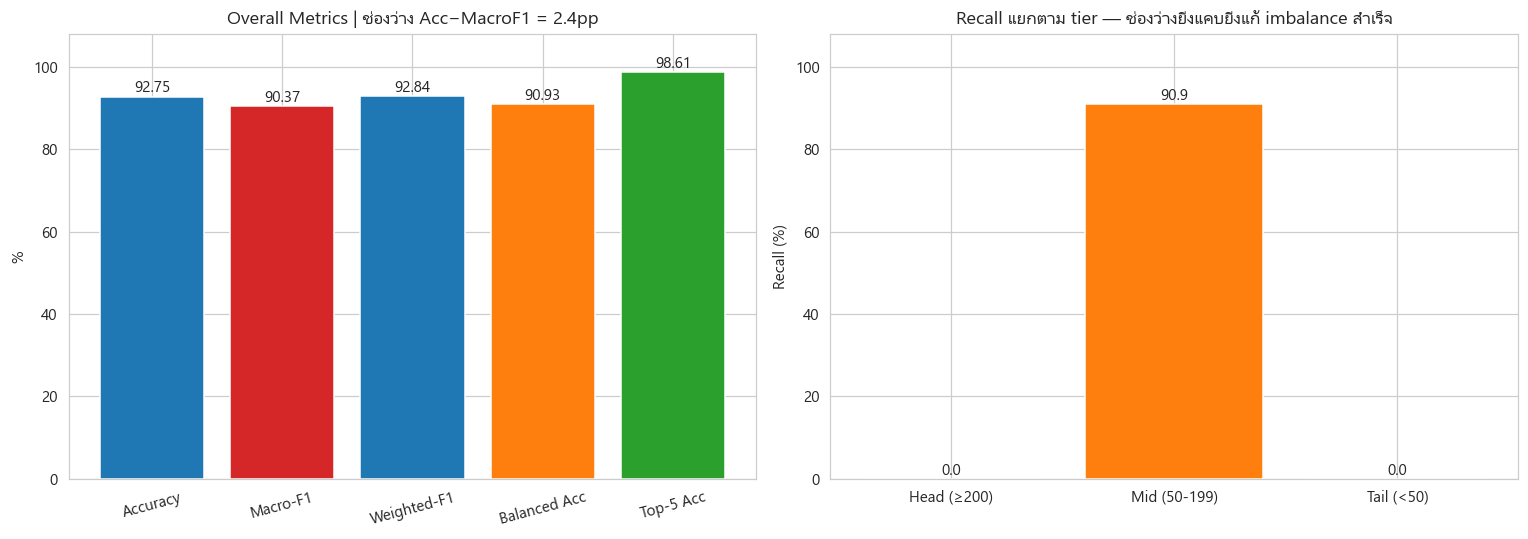


ช่องว่าง Head−Tail = 0.0 pp


In [4]:
gap = result.accuracy - result.macro_f1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

m = {"Accuracy": result.accuracy, "Macro-F1": result.macro_f1,
     "Weighted-F1": result.weighted_f1, "Balanced Acc": result.balanced_accuracy,
     "Top-5 Acc": result.top5_accuracy}
bars = axes[0].bar(m.keys(), [v*100 for v in m.values()],
                   color=["#1f77b4","#d62728","#1f77b4","#ff7f0e","#2ca02c"])
for b, v in zip(bars, m.values()):
    axes[0].text(b.get_x()+b.get_width()/2, v*100+1, f"{v*100:.2f}",
                 ha="center", fontsize=10)
axes[0].set_ylim(0, 108); axes[0].set_ylabel("%")
axes[0].set_title(f"Overall Metrics | ช่องว่าง Acc−MacroF1 = {gap*100:.1f}pp")
plt.setp(axes[0].get_xticklabels(), rotation=15)

t = {"Head (≥200)": result.head_recall, "Mid (50-199)": result.mid_recall,
     "Tail (<50)": result.tail_recall}
bars = axes[1].bar(t.keys(), [v*100 for v in t.values()],
                   color=["#2ca02c","#ff7f0e","#d62728"])
for b, v in zip(bars, t.values()):
    axes[1].text(b.get_x()+b.get_width()/2, v*100+1, f"{v*100:.1f}", ha="center")
axes[1].set_ylim(0, 108); axes[1].set_ylabel("Recall (%)")
axes[1].set_title("Recall แยกตาม tier — ช่องว่างยิ่งแคบยิ่งแก้ imbalance สำเร็จ")

fig.tight_layout(); fig.savefig(FIG_DIR/"err_01_overall.png", dpi=150); plt.show()
print(f"\nช่องว่าง Head−Tail = {(result.head_recall-result.tail_recall)*100:.1f} pp")

## 2. Per-class — คลาสไหนพัง

In [5]:
pc = per_class_table(result, sort_by="recall")
pc["raw_count"] = [raw_counts[l] for l in pc["label"]]
pc["tier"] = pd.cut(pc["raw_count"], [-1, 49, 79, 99, 10**9],
                    labels=["<50", "50-79", "80-99", ">=100"])
display(pc.head(20).style.format({"precision":"{:.3f}","recall":"{:.3f}","f1":"{:.3f}"})
          .background_gradient(subset=["recall"], cmap="RdYlGn", vmin=0, vmax=1))
pc.to_csv(FIG_DIR/"err_per_class.csv", index=False, encoding="utf-8-sig")

print(f"คลาสที่ recall = 0  : {(pc['recall']==0).sum()} → "
      f"{' '.join(pc.loc[pc['recall']==0,'class'])}")
print(f"คลาสที่ recall < 50%: {(pc['recall']<0.5).sum()}")
print(f"คลาสที่ recall = 100%: {(pc['recall']==1).sum()}")

,label,class,train_count,val_support,precision,recall,f1,raw_count,tier
0,2,ฃ,81,1,0.000,0.000,0.000,81,80-99
1,70,๘,85,5,0.333,0.200,0.250,85,80-99
2,46,ึ,83,3,0.167,0.333,0.222,83,80-99
3,47,ื,92,12,1.000,0.583,0.737,92,80-99
4,43,า,100,20,0.800,0.600,0.686,100,>=100
5,49,ู,100,20,0.609,0.700,0.651,100,>=100
6,41,ฯ,84,4,1.000,0.750,0.857,84,80-99
7,15,ด,100,20,0.889,0.800,0.842,100,>=100
8,37,ห,100,20,1.000,0.800,0.889,100,>=100
9,65,๓,85,5,1.000,0.800,0.889,85,80-99


คลาสที่ recall = 0  : 1 → ฃ
คลาสที่ recall < 50%: 3
คลาสที่ recall = 100%: 42


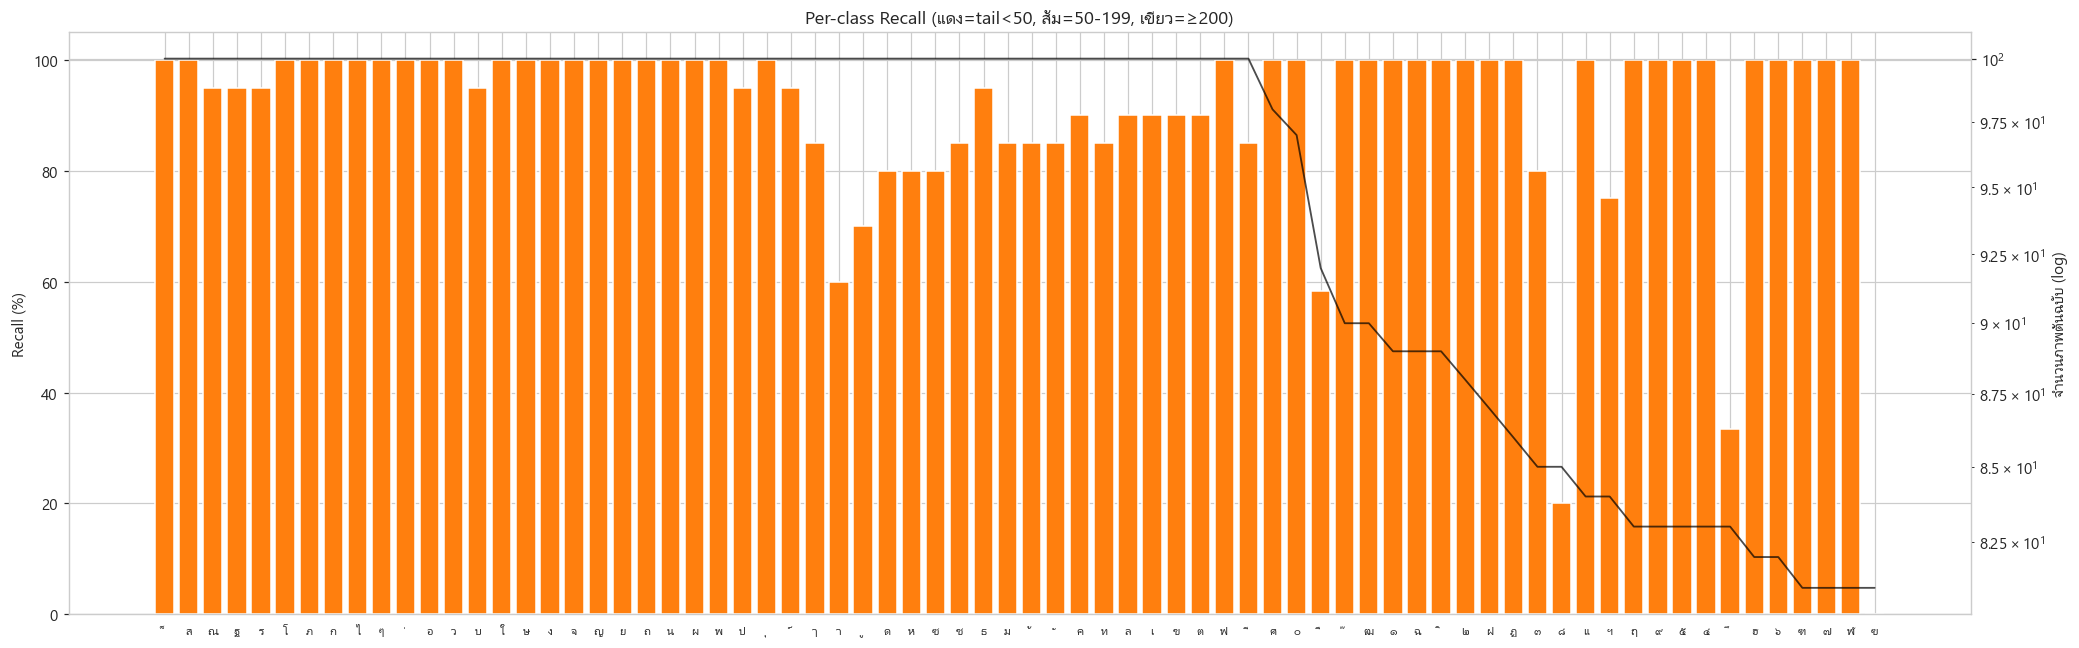

In [6]:
d = pc.sort_values("raw_count", ascending=False)
x = np.arange(len(d))
fig, ax1 = plt.subplots(figsize=(19, 6))
cols = ["#d62728" if c<50 else "#ff7f0e" if c<200 else "#2ca02c" for c in d["raw_count"]]
ax1.bar(x, d["recall"]*100, color=cols)
ax1.set_ylabel("Recall (%)"); ax1.set_ylim(0,105)
ax1.set_xticks(x); ax1.set_xticklabels(d["class"], fontsize=8)
ax2 = ax1.twinx(); ax2.plot(x, d["raw_count"], c="black", lw=1.2, alpha=.7)
ax2.set_yscale("log"); ax2.set_ylabel("จำนวนภาพต้นฉบับ (log)")
ax1.set_title("Per-class Recall (แดง=tail<50, ส้ม=50-199, เขียว=≥200)")
fig.tight_layout(); fig.savefig(FIG_DIR/"err_02_per_class_recall.png", dpi=150); plt.show()

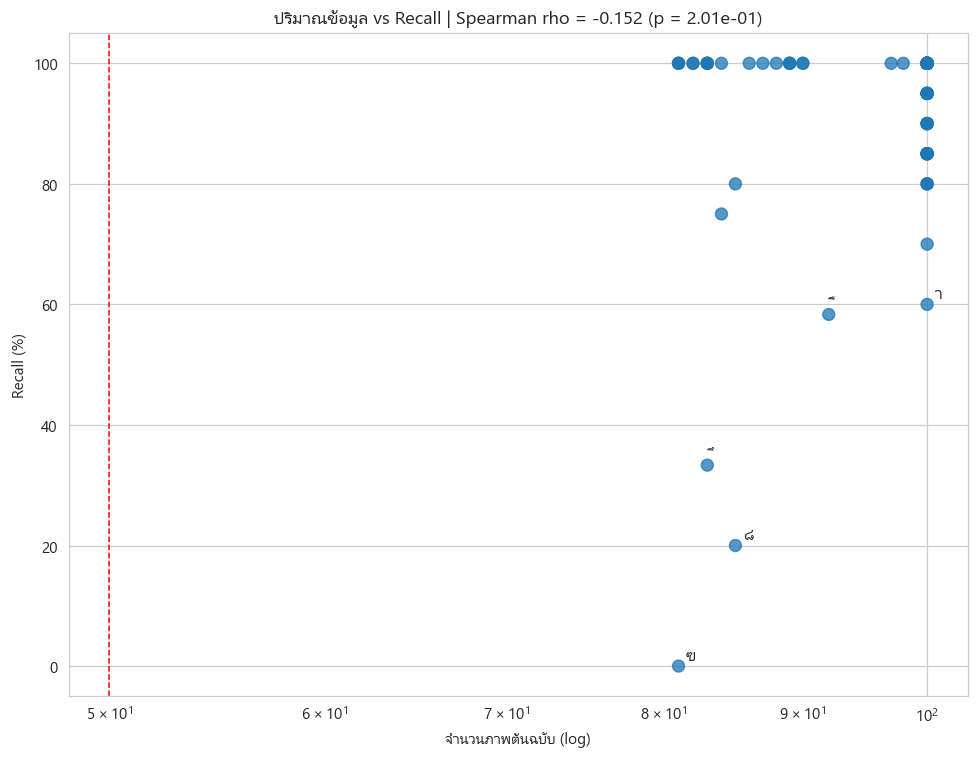

ρ = -0.152 -> ความสัมพันธ์ไม่ชัด


In [7]:
# พิสูจน์เชิงสถิติว่า "ข้อมูลน้อย -> recall ต่ำ" จริงไหม
from scipy.stats import spearmanr
v = pc[pc["val_support"] > 0]
rho, p = spearmanr(v["raw_count"], v["recall"])

fig, ax = plt.subplots(figsize=(9,7))
ax.scatter(v["raw_count"], v["recall"]*100, s=60, alpha=.75,
           c=np.where(v["raw_count"]<50, "#d62728", "#1f77b4"))
for _, r in v[(v["recall"]<0.7)|(v["raw_count"]<50)].iterrows():
    ax.annotate(r["class"], (r["raw_count"], r["recall"]*100),
                fontsize=11, xytext=(5,4), textcoords="offset points")
ax.set_xscale("log"); ax.axvline(50, ls="--", c="red", lw=1)
ax.set_xlabel("จำนวนภาพต้นฉบับ (log)"); ax.set_ylabel("Recall (%)")
ax.set_title(f"ปริมาณข้อมูล vs Recall | Spearman rho = {rho:.3f} (p = {p:.2e})")
fig.tight_layout(); fig.savefig(FIG_DIR/"err_03_recall_vs_count.png", dpi=150); plt.show()
print(f"ρ = {rho:.3f} -> {'มีความสัมพันธ์ชัดเจน' if abs(rho)>0.5 else 'ความสัมพันธ์ไม่ชัด'}")

## 3. Confusion Matrix + คู่ที่สับสนที่สุด

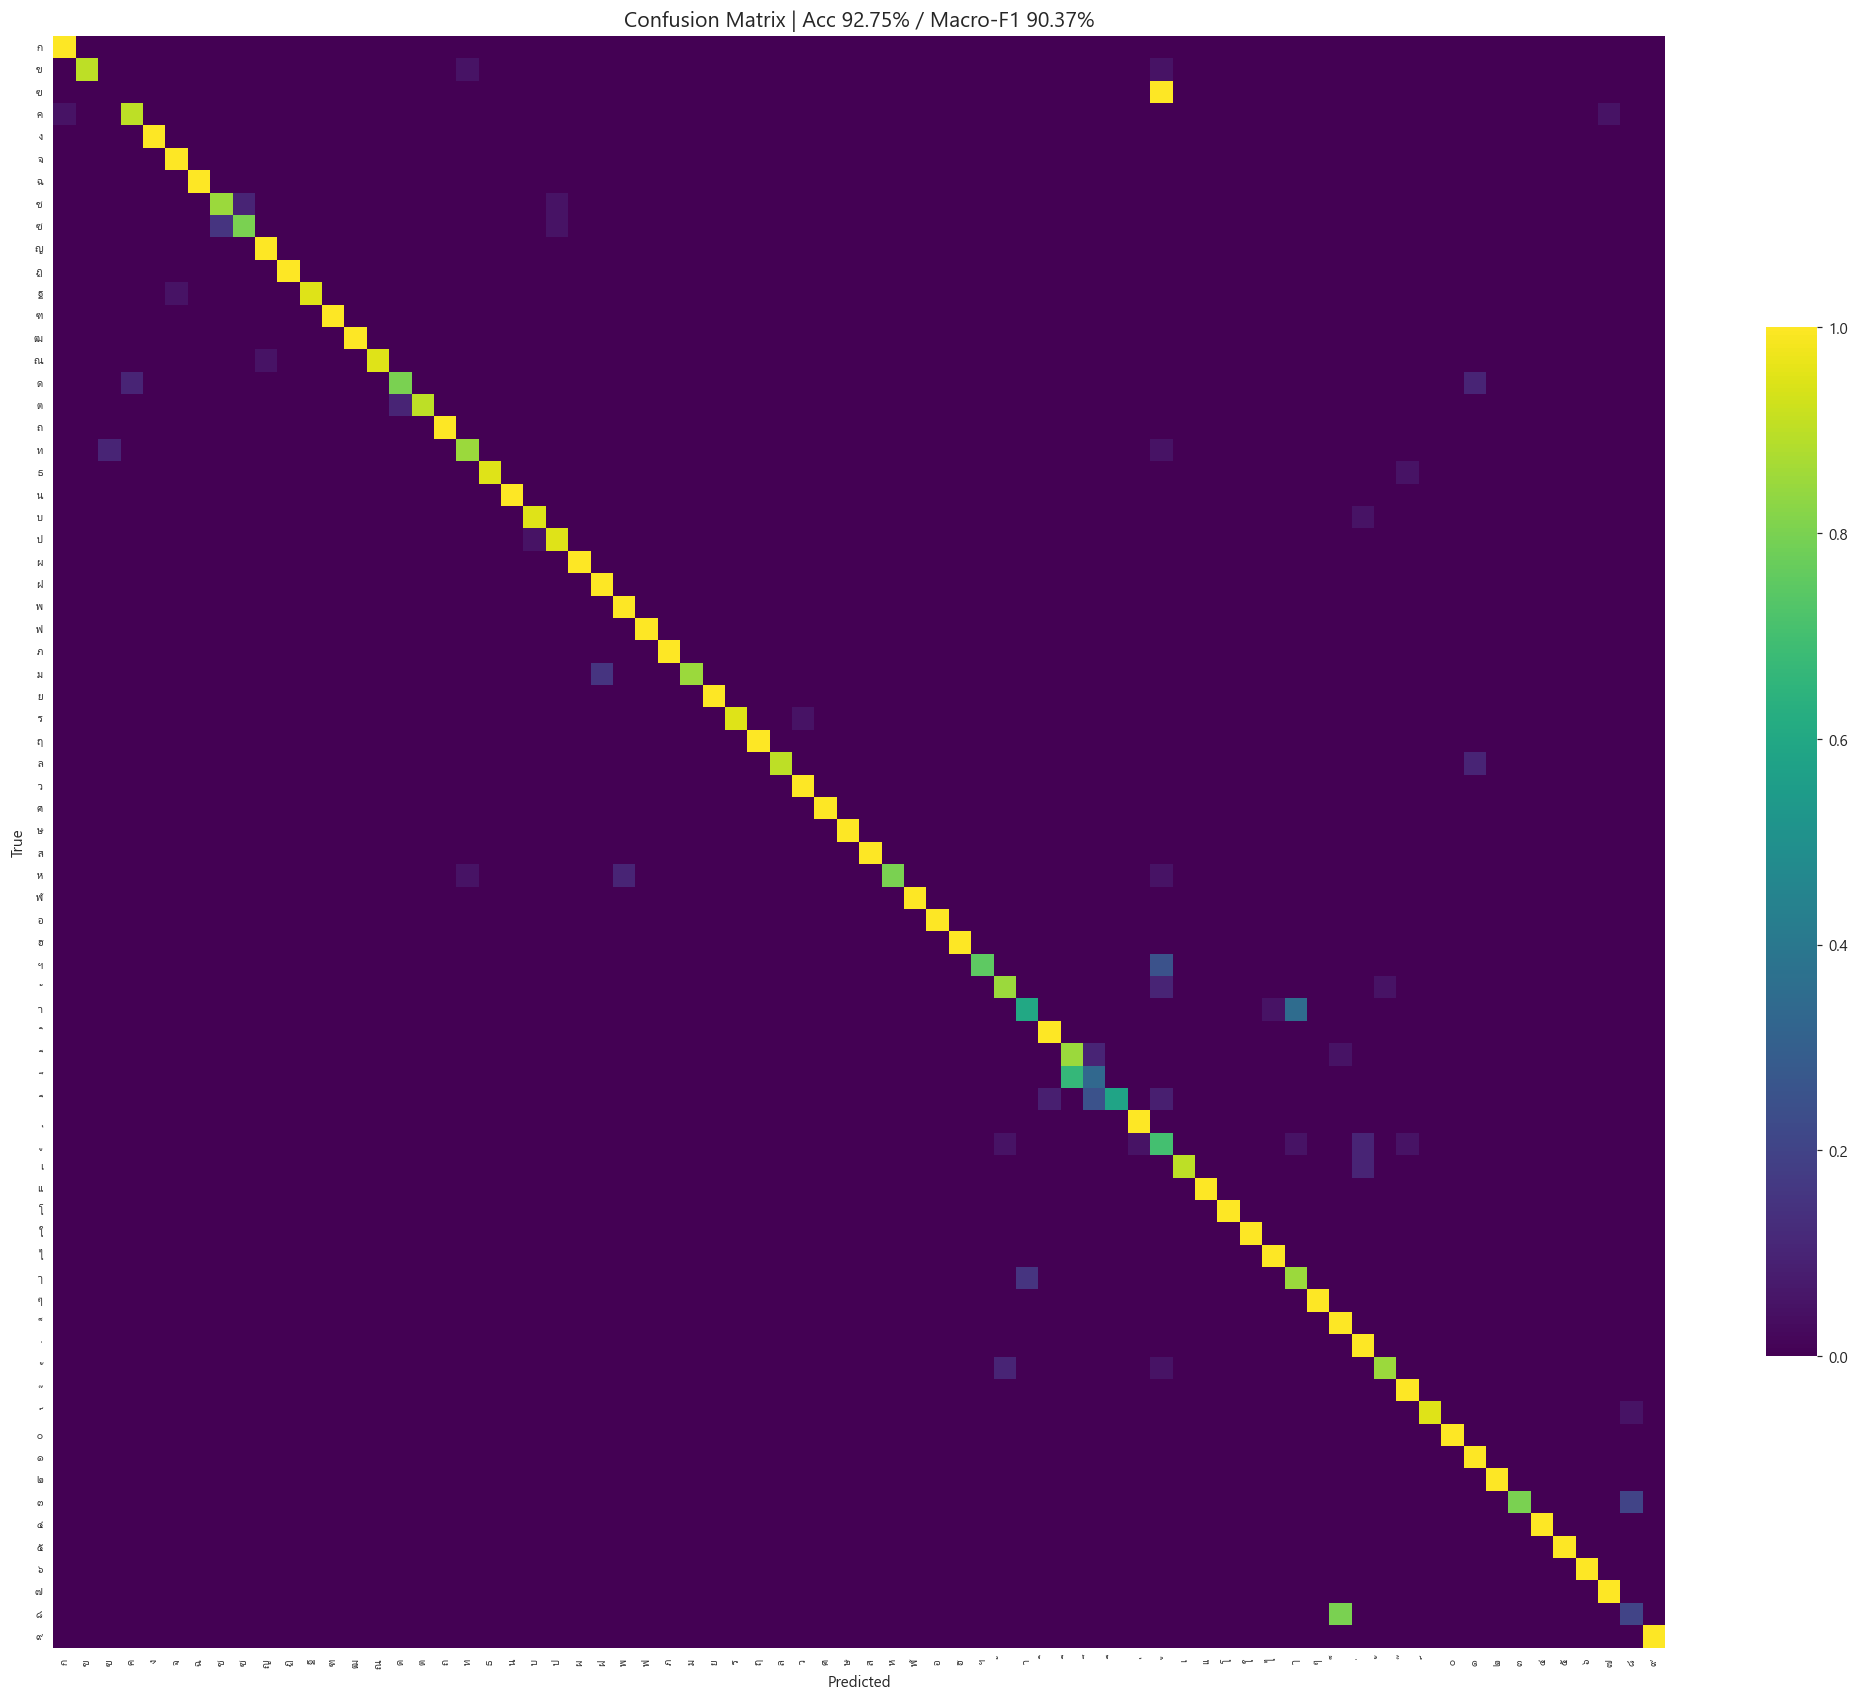

In [8]:
cmat = get_confusion_matrix(targets, preds, n_cls, normalize=True)
fig, ax = plt.subplots(figsize=(19, 16))
sns.heatmap(cmat, xticklabels=names, yticklabels=names, cmap="viridis",
            vmin=0, vmax=1, square=True, cbar_kws={"shrink":.6}, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix | Acc {result.accuracy*100:.2f}% / "
             f"Macro-F1 {result.macro_f1*100:.2f}%", fontsize=14)
plt.xticks(fontsize=7, rotation=90); plt.yticks(fontsize=7, rotation=0)
fig.tight_layout(); fig.savefig(FIG_DIR/"err_04_confusion_full.png", dpi=140); plt.show()

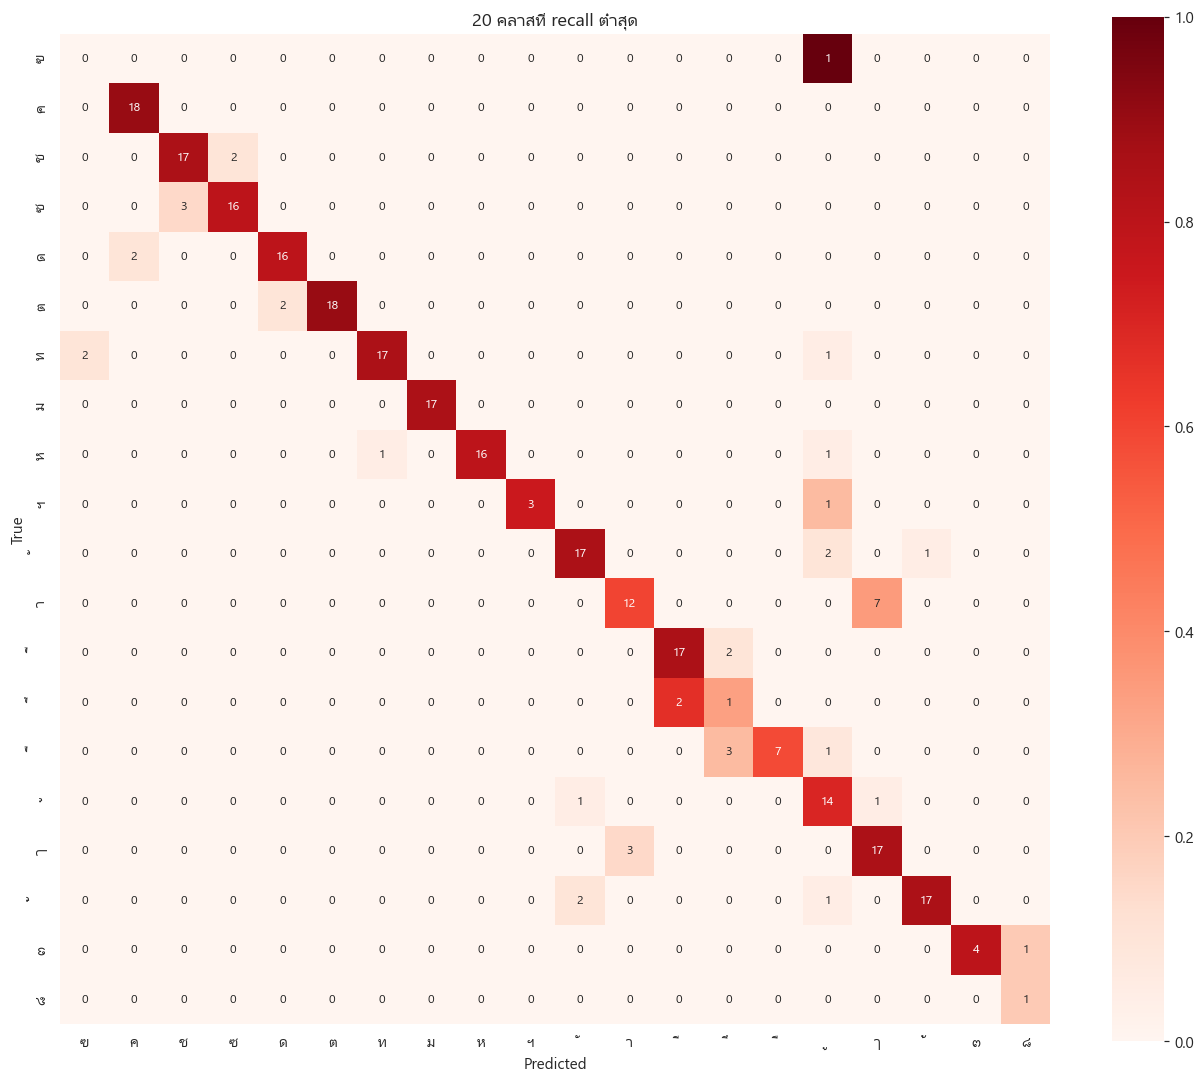

In [9]:
from sklearn.metrics import confusion_matrix as skcm
worst = sorted(pc.nsmallest(20, "recall")["label"].tolist())

# คำนวณแบบเต็ม 72 คลาสก่อน เพื่อไม่ให้ตัวอย่างที่ทายหลุดกลุ่มหายไป
full_cm = skcm(targets, preds, labels=np.arange(n_cls))
with np.errstate(divide="ignore", invalid="ignore"):
    full_cmn = np.nan_to_num(full_cm.astype(float) / full_cm.sum(1, keepdims=True))

sub = full_cm[np.ix_(worst, worst)]
subn = full_cmn[np.ix_(worst, worst)]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(subn, annot=sub, fmt="d", cmap="Reds", vmin=0, vmax=1, square=True,
            xticklabels=[names[i] for i in worst],
            yticklabels=[names[i] for i in worst], annot_kws={"size":8}, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("20 คลาสที่ recall ต่ำสุด")
fig.tight_layout(); fig.savefig(FIG_DIR/"err_05_confusion_worst.png", dpi=150); plt.show()

In [10]:
pairs = pd.DataFrame(top_confused_pairs(targets, preds, names, n_cls, top_k=30))
pairs["n_true_raw"] = [raw_counts[i] for i in pairs["true_idx"]]
pairs["n_pred_raw"] = [raw_counts[i] for i in pairs["pred_idx"]]
pairs["tail→head"] = pairs["n_pred_raw"] > pairs["n_true_raw"]*3
display(pairs.head(20).style.format({"rate":"{:.1%}"}))
pairs.to_csv(FIG_DIR/"err_confused_pairs.csv", index=False, encoding="utf-8-sig")

n_bias = pairs["tail→head"].sum()
print(f"\n{n_bias}/{len(pairs)} คู่ เป็นการทายจากคลาสเล็กไปคลาสใหญ่")
print("→ ถ้าสัดส่วนนี้สูง แปลว่ายังมี long-tail bias เหลืออยู่ ลองเพิ่ม τ ของ Logit Adjustment")

,true,pred,true_idx,pred_idx,count,rate,n_true_raw,n_pred_raw,tail→head
0,า,ๅ,43,55,7,35.0%,100,100,False
1,๘,็,70,57,4,80.0%,85,100,False
2,ื,ึ,47,46,3,25.0%,92,83,False
3,ซ,ช,8,7,3,15.0%,100,100,False
4,ม,ฝ,28,24,3,15.0%,100,87,False
5,ๅ,า,55,43,3,15.0%,100,100,False
6,ึ,ี,46,45,2,66.7%,83,100,False
7,ช,ซ,7,8,2,10.0%,100,100,False
8,ด,ค,15,3,2,10.0%,100,100,False
9,ด,๑,15,63,2,10.0%,100,89,False



0/30 คู่ เป็นการทายจากคลาสเล็กไปคลาสใหญ่
→ ถ้าสัดส่วนนี้สูง แปลว่ายังมี long-tail bias เหลืออยู่ ลองเพิ่ม τ ของ Logit Adjustment


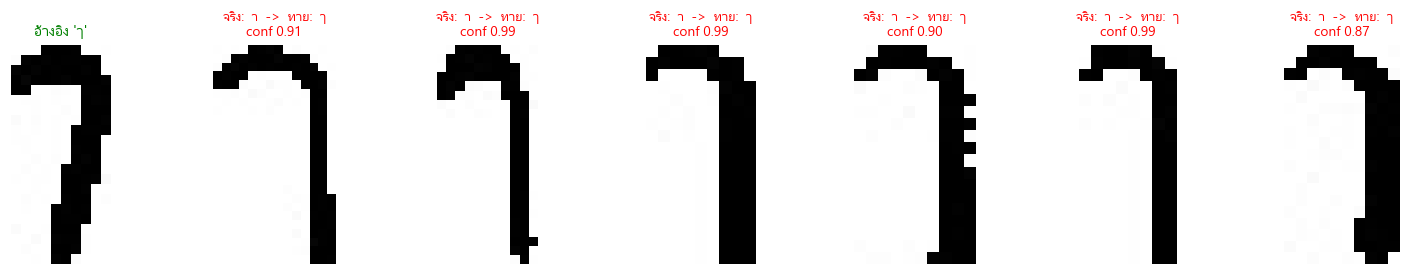

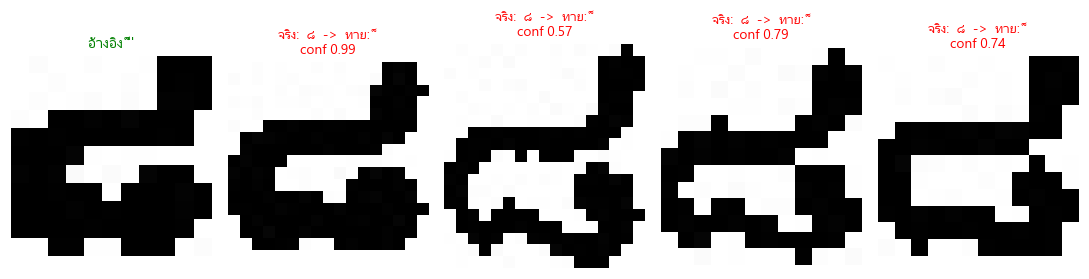

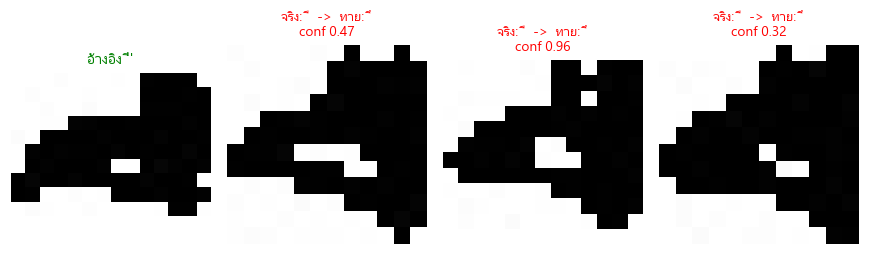

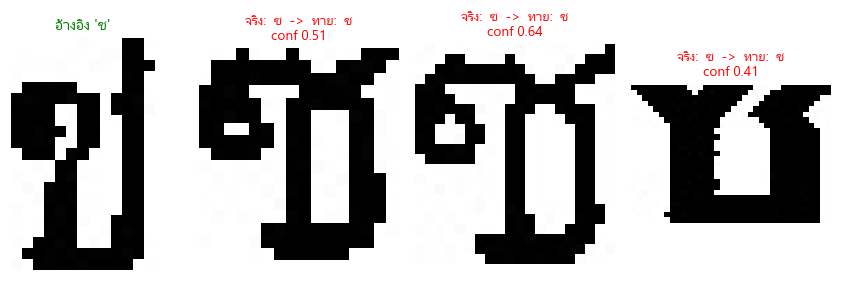

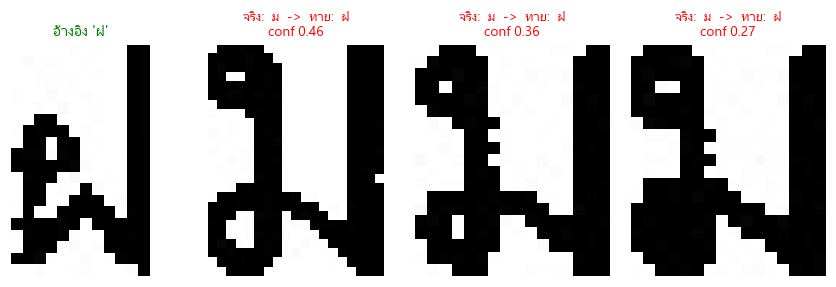

In [11]:
# ดูภาพจริงของคู่ที่สับสนที่สุด — ตรงนี้ได้สไลด์ดี ๆ หนึ่งหน้า
def show_confusion_examples(true_c, pred_c, n=6):
    ti, pi = cm_map.char_to_label[true_c], cm_map.char_to_label[pred_c]
    idx = np.where((targets==ti) & (preds==pi))[0][:n]
    if len(idx)==0: print(f"ไม่มีตัวอย่าง {true_c}→{pred_c}"); return
    fig, axes = plt.subplots(1, len(idx)+1, figsize=((len(idx)+1)*2, 2.6))
    axes = np.atleast_1d(axes)
    ref = val_df[val_df["label"]==pi]["filepath"]
    axes[0].imshow(read_image(ref.iloc[0]) if len(ref) else np.zeros((64,64,3),np.uint8))
    axes[0].set_title(f"อ้างอิง '{pred_c}'", fontsize=10, color="green")
    for k, i in enumerate(idx):
        axes[k+1].imshow(read_image(val_df.iloc[i]["filepath"]))
        axes[k+1].set_title(f"จริง:  {true_c}  ->  ทาย:  {pred_c}\nconf {probs[i,pi]:.2f}",
                            fontsize=9, color="red")
    for a in axes: a.axis("off")
    fig.tight_layout(); plt.show()

for _, r in pairs.head(5).iterrows():
    show_confusion_examples(r["true"], r["pred"])

,group,support,accuracy,within_group_error,outside_group_error
0,ิ ี ึ ื,44,77.3%,18.2%,4.5%
1,า ๅ ว,60,81.7%,16.7%,1.7%
2,ช ซ,40,82.5%,12.5%,5.0%
3,็ ๘,25,84.0%,16.0%,0.0%
4,ข ฃ,21,85.7%,0.0%,14.3%
5,ท ฑ,21,85.7%,0.0%,14.3%
6,ด ต ค,60,86.7%,6.7%,6.7%
7,๐ ๑ ๒ ๓ ๔ ๕ ๖ ๗ ๘ ๙,56,91.1%,1.8%,7.1%
8,น ม,40,92.5%,0.0%,7.5%
9,๓ ๗ ๊,16,93.8%,0.0%,6.2%


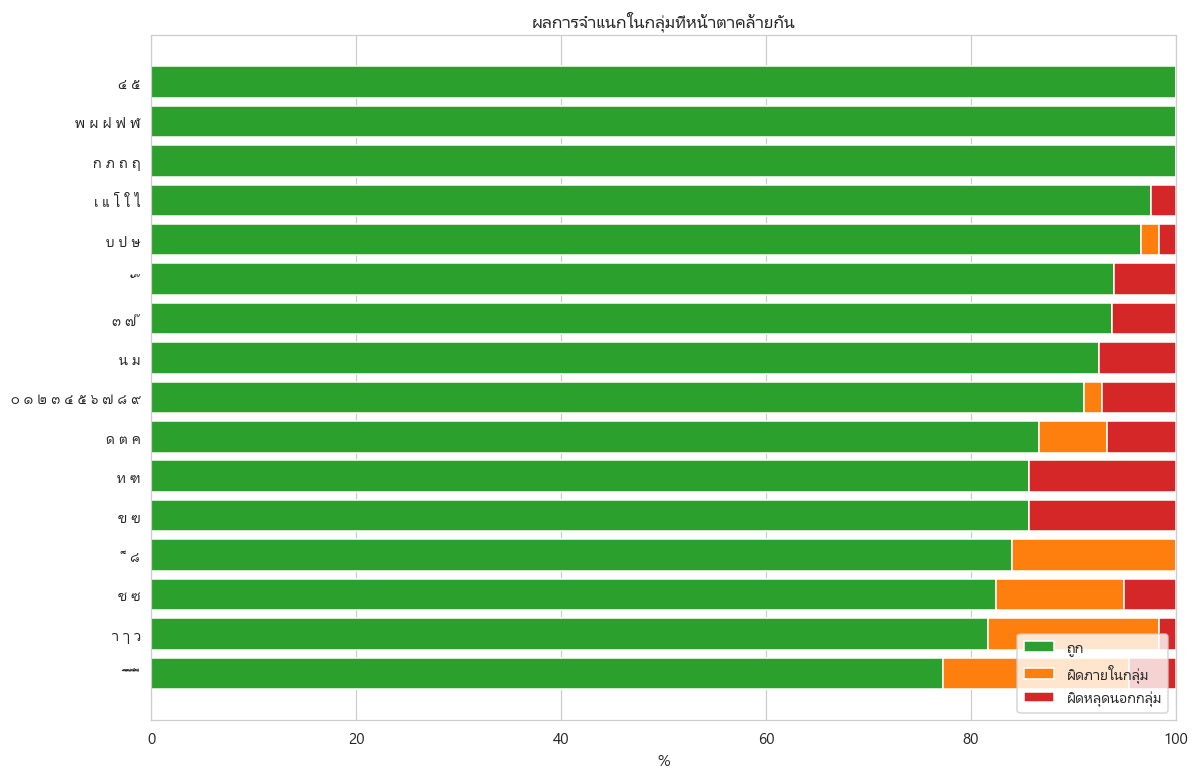

In [12]:
groups = pd.DataFrame(group_analysis(targets, preds,
                                     cm_map.similar_groups_as_labels(), names))
display(groups.style.format({"accuracy":"{:.1%}", "within_group_error":"{:.1%}",
                             "outside_group_error":"{:.1%}"})
        .background_gradient(subset=["accuracy"], cmap="RdYlGn", vmin=0, vmax=1))

fig, ax = plt.subplots(figsize=(11, max(4, len(groups)*0.45)))
y = np.arange(len(groups))
ax.barh(y, groups["accuracy"]*100, color="#2ca02c", label="ถูก")
ax.barh(y, groups["within_group_error"]*100, left=groups["accuracy"]*100,
        color="#ff7f0e", label="ผิดภายในกลุ่ม")
ax.barh(y, groups["outside_group_error"]*100,
        left=(groups["accuracy"]+groups["within_group_error"])*100,
        color="#d62728", label="ผิดหลุดนอกกลุ่ม")
ax.set_yticks(y); ax.set_yticklabels(groups["group"], fontsize=10)
ax.set_xlabel("%"); ax.legend(loc="lower right")
ax.set_title("ผลการจำแนกในกลุ่มที่หน้าตาคล้ายกัน")
fig.tight_layout(); fig.savefig(FIG_DIR/"err_06_groups.png", dpi=150); plt.show()

## 4. Confidence & Calibration
ถ้าโมเดล **ผิดแบบมั่นใจสูง** แปลว่า overconfident → เพิ่ม label smoothing หรือ margin

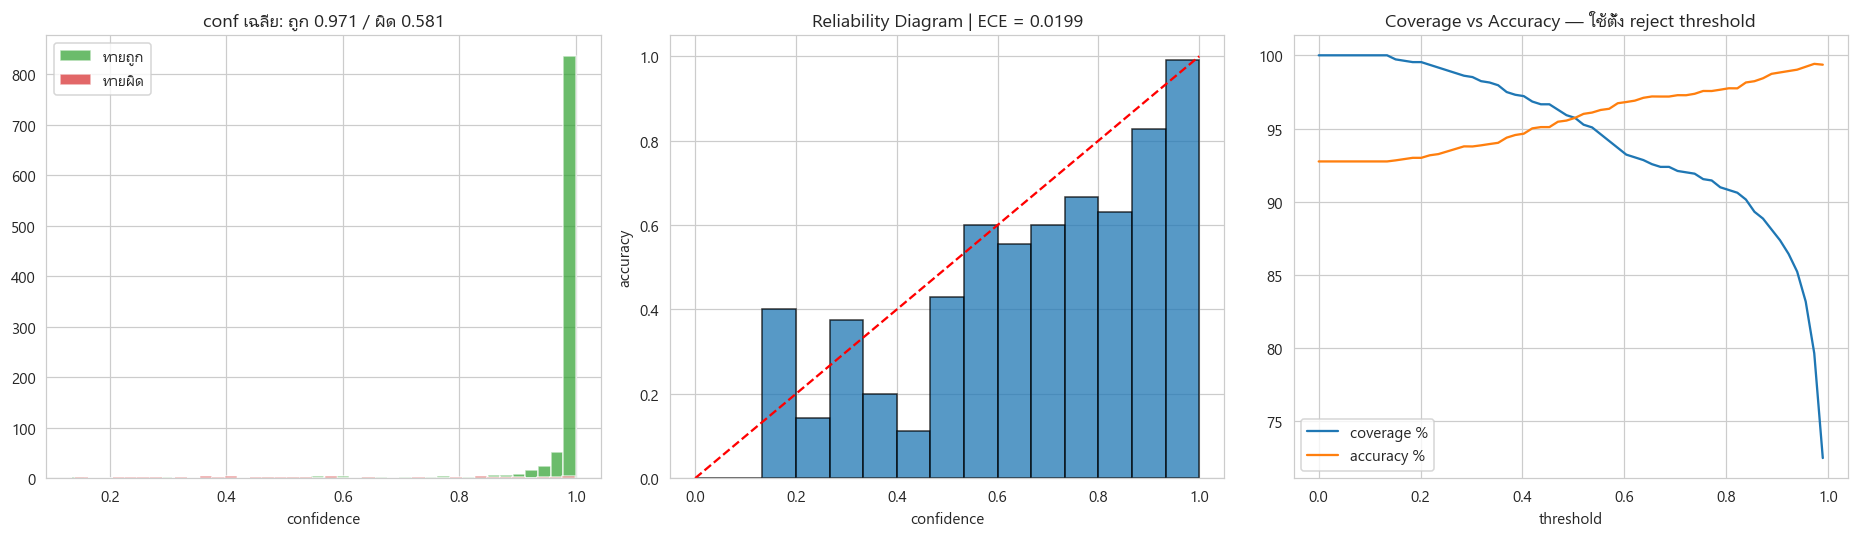

ผิดแบบมั่นใจ > 90%: 11 ภาพ (1.02% ของ val)
ECE = 0.0199 → calibrate ดี


In [13]:
conf = probs.max(1)
correct = (preds == targets)
ece_bins = 15
bins = np.linspace(0, 1, ece_bins+1)
acc_b, conf_b, cnt_b = [], [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    m = (conf > lo) & (conf <= hi)
    acc_b.append(correct[m].mean() if m.sum() else 0)
    conf_b.append(conf[m].mean() if m.sum() else (lo+hi)/2)
    cnt_b.append(m.sum())
acc_b, conf_b, cnt_b = map(np.array, (acc_b, conf_b, cnt_b))
ece = np.sum(cnt_b/cnt_b.sum() * np.abs(acc_b - conf_b))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].hist(conf[correct], bins=40, alpha=.7, label="ทายถูก", color="#2ca02c")
axes[0].hist(conf[~correct], bins=40, alpha=.7, label="ทายผิด", color="#d62728")
axes[0].set_xlabel("confidence"); axes[0].legend()
axes[0].set_title(f"conf เฉลี่ย: ถูก {conf[correct].mean():.3f} / "
                  f"ผิด {conf[~correct].mean():.3f}")

axes[1].bar(bins[:-1], acc_b, width=1/ece_bins, align="edge",
            edgecolor="black", alpha=.75, color="#1f77b4")
axes[1].plot([0,1],[0,1],"--",c="red")
axes[1].set_xlabel("confidence"); axes[1].set_ylabel("accuracy")
axes[1].set_title(f"Reliability Diagram | ECE = {ece:.4f}")

ths = np.linspace(0, .99, 60)
cov = [(conf>=t).mean() for t in ths]
sel = [correct[conf>=t].mean() if (conf>=t).sum() else np.nan for t in ths]
axes[2].plot(ths, np.array(cov)*100, label="coverage %")
axes[2].plot(ths, np.array(sel)*100, label="accuracy %")
axes[2].set_xlabel("threshold"); axes[2].legend()
axes[2].set_title("Coverage vs Accuracy — ใช้ตั้ง reject threshold")

fig.tight_layout(); fig.savefig(FIG_DIR/"err_07_confidence.png", dpi=150); plt.show()

hi_wrong = (~correct) & (conf > 0.9)
print(f"ผิดแบบมั่นใจ > 90%: {hi_wrong.sum()} ภาพ ({hi_wrong.mean()*100:.2f}% ของ val)")
print(f"ECE = {ece:.4f} → {'calibrate ดี' if ece<0.05 else 'overconfident ควรเพิ่ม label smoothing'}")

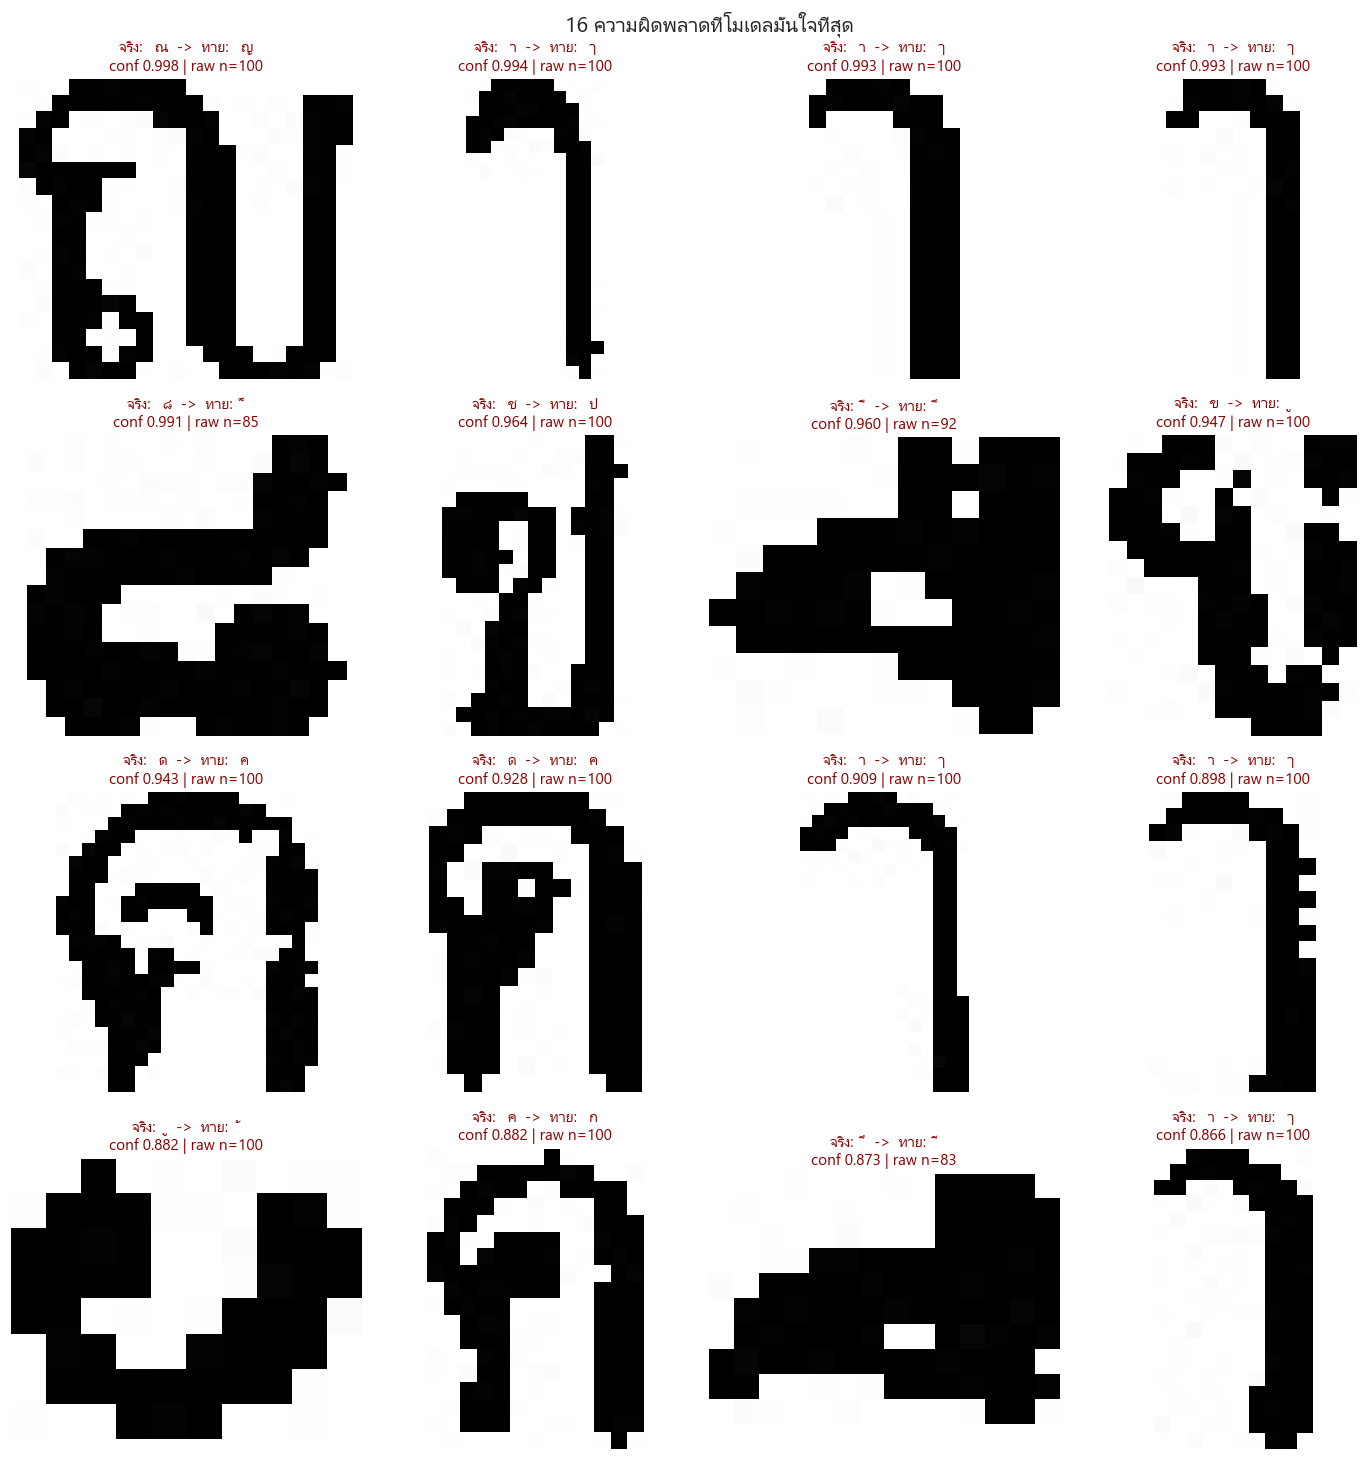

In [14]:
# แกลเลอรีความผิดพลาดที่มั่นใจที่สุด — ดูว่าเป็น "ภาพกำกวมจริง" หรือ "โมเดลพลาด"
wrong_idx = np.where(~correct)[0]
order = wrong_idx[np.argsort(-conf[wrong_idx])][:16]

fig, axes = plt.subplots(4, 4, figsize=(13, 13.5))
for ax in axes.ravel(): ax.axis("off")  # ปิดแกนเปล่าทุกช่องล่วงหน้า

for ax, i in zip(axes.ravel(), order):
    ax.imshow(read_image(val_df.iloc[i]["filepath"]))
    ax.set_title(f"จริง:   {names[targets[i]]}  ->  ทาย:   {names[preds[i]]}\n"
                 f"conf {conf[i]:.3f} | raw n={raw_counts[targets[i]]:,}",
                 fontsize=10, color="darkred")
fig.suptitle("16 ความผิดพลาดที่โมเดลมั่นใจที่สุด", fontsize=14)
fig.tight_layout(); fig.savefig(FIG_DIR/"err_08_gallery.png", dpi=140); plt.show()

## 5. Grad-CAM — โมเดลมองตรงไหนตอนทายผิด

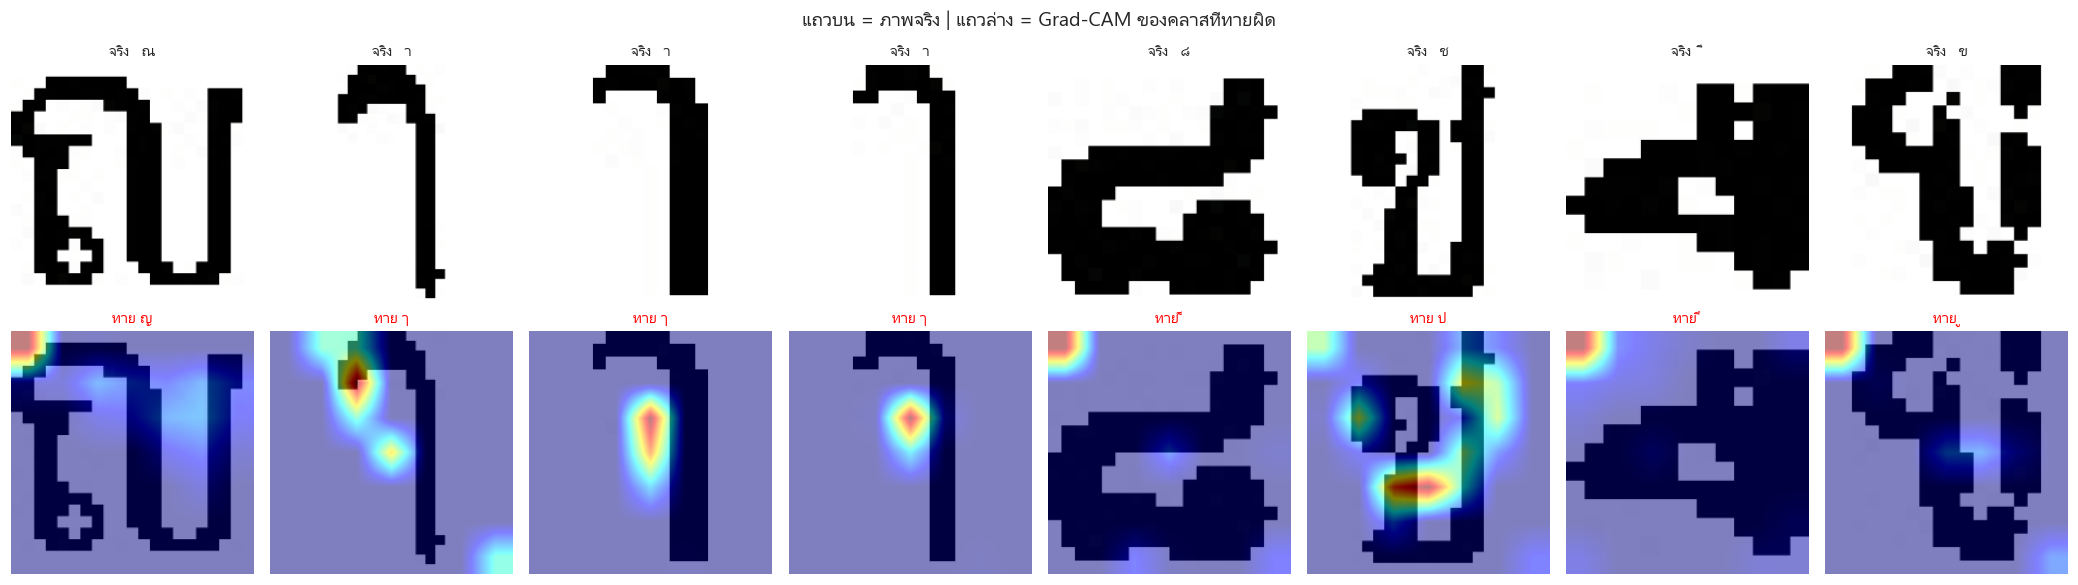

In [15]:
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

    layer = model.get_cam_target_layer()
    cam = GradCAM(model=model, target_layers=[layer])
    picks = order[:8]

    fig, axes = plt.subplots(2, 8, figsize=(19, 5.5))
    for ax in axes.ravel(): ax.axis("off")  # ปิดแกนเปล่าทุกช่องล่วงหน้า

    for c, i in enumerate(picks):
        img, lbl = val_ds[int(i)]
        rgb = denormalize(img).permute(1,2,0).cpu().numpy()
        axes[0, c].imshow(rgb)
        axes[0, c].set_title(f"จริง   {names[targets[i]]}", fontsize=10)
        
        g_true = cam(input_tensor=img.unsqueeze(0).to(device),
                     targets=[ClassifierOutputTarget(int(preds[i]))])[0]
        axes[1, c].imshow(show_cam_on_image(rgb, g_true, use_rgb=True))
        axes[1, c].set_title(f"ทาย {names[preds[i]]}", fontsize=10, color="red")

    fig.suptitle("แถวบน = ภาพจริง | แถวล่าง = Grad-CAM ของคลาสที่ทายผิด", fontsize=13)
    fig.tight_layout(); fig.savefig(FIG_DIR/"err_09_gradcam.png", dpi=140); plt.show()
except ImportError:
    print("ติดตั้งก่อน: pip install grad-cam")

## 6. Embedding Space — คลาสไหนทับกันใน feature space
ถ้าใช้ ArcFace แล้วได้ผล คลาสต่าง ๆ ควรแยกเป็นกลุ่มชัดเจน

In [16]:
@torch.no_grad()
def extract_embeddings(ds, bs=128):
    dl = DataLoader(ds, batch_size=bs, shuffle=False, num_workers=8, pin_memory=True)
    embs, ys = [], []
    for x, y in tqdm(dl, desc="embedding"):
        x = x.to(device)
        if cfg.get_path("hardware.channels_last", True):
            x = x.contiguous(memory_format=torch.channels_last)
        with torch.autocast(device.type, dtype=amp_dtype, enabled=amp):
            e = model.extract_embedding(x)
        embs.append(F.normalize(e.float(), dim=1).cpu()); ys.append(y)
    return torch.cat(embs).numpy(), torch.cat(ys).numpy()

emb, emb_y = extract_embeddings(val_ds)
print("embedding shape:", emb.shape)

embedding:   0%|          | 0/9 [00:30<?, ?it/s]

embedding shape: (1076, 512)


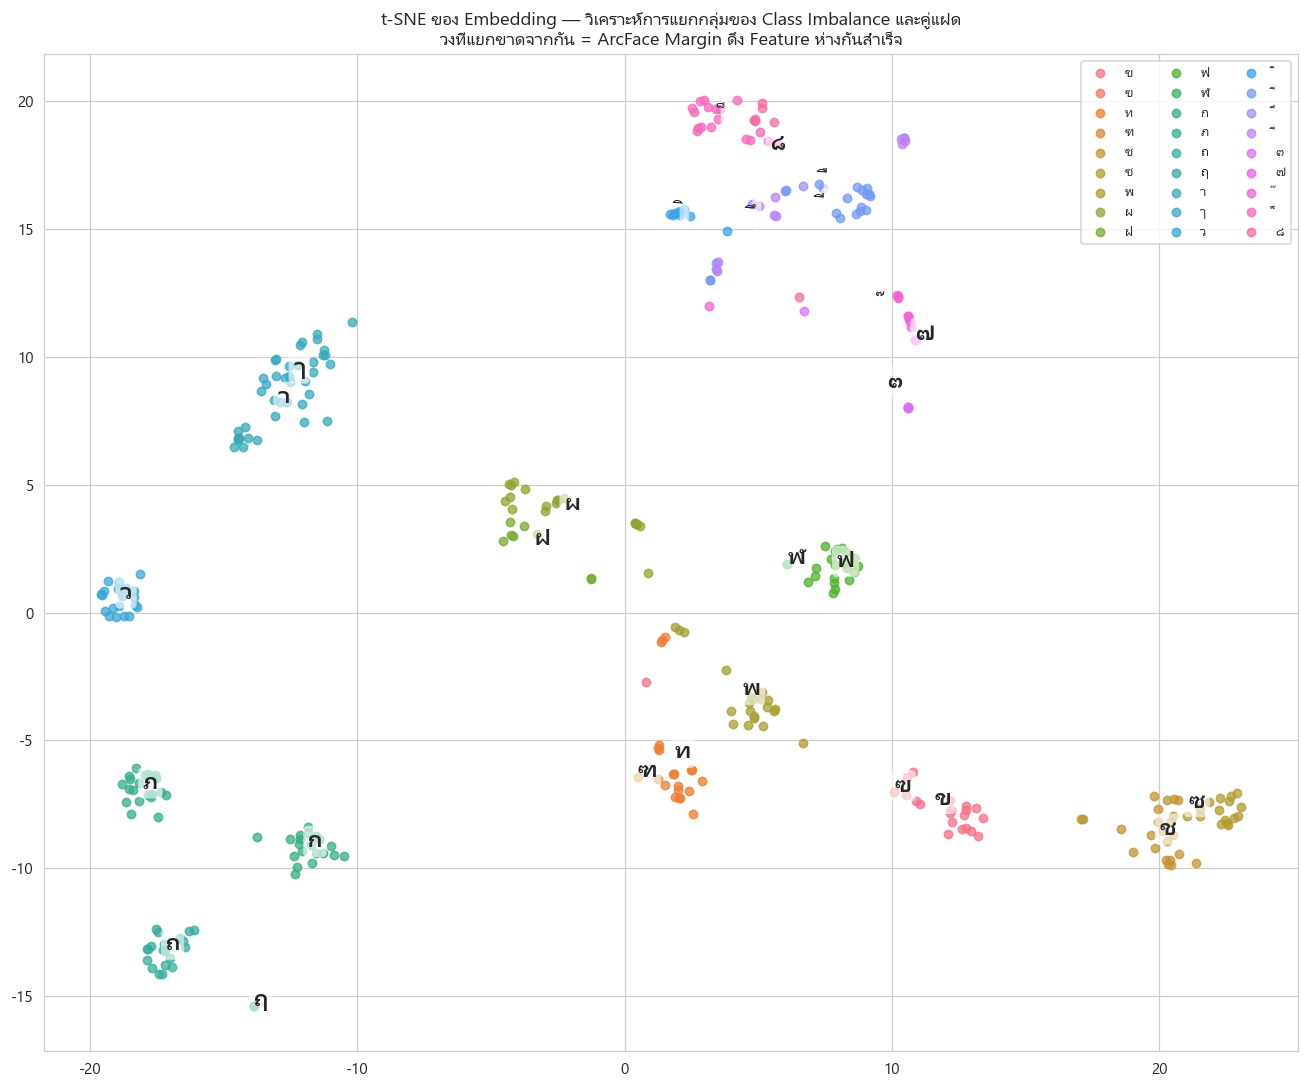

In [17]:
from sklearn.manifold import TSNE

# ใส่ตัวอักษรที่ต้องการวิเคราะห์เพิ่มเติมได้ตามใจชอบตรงนี้
focus = [
    # คู่แฝด + Tail Imbalance
    "ข", "ฃ", "ท", "ฑ", "ช", "ซ", "พ", "ผ", "ฝ", "ฟ", "ฬ",
    # ทรงหัวเข้า-หัวออก
    "ก", "ภ", "ถ", "ฤ","า", "ๅ", "ว",
    # สระบนที่มักสับสน
    "ิ", "ี", "ึ", "ื",
    # ตัวเลขและเครื่องหมาย Tail
    "๓", "๗", "๊", "็", "๘"
]

focus_lbl = [cm_map.char_to_label[c] for c in focus if c in cm_map.char_to_label]
mask = np.isin(emb_y, focus_lbl)
n_samples = int(mask.sum())

# คุม perplexity ให้ปลอดภัย ป้องกัน error กรณีเลือกคลาสที่มีตัวอย่างรวมกันน้อย
perp = min(30, max(1, (n_samples - 1) // 3))

Z = TSNE(n_components=2, perplexity=perp,
         init="pca", random_state=42, n_iter=1000).fit_transform(emb[mask])

fig, ax = plt.subplots(figsize=(12, 10))

# สลับ palette อัตโนมัติ: ถ้า <= 20 ใช้ tab20 ถ้าเกิน 20 ใช้ husl เพื่อไม่ให้สีซ้ำ
pal = sns.color_palette("tab20" if len(focus_lbl) <= 20 else "husl", len(focus_lbl))

for k, l in enumerate(focus_lbl):
    m = emb_y[mask] == l
    if m.sum() == 0:
        continue
    ax.scatter(Z[m, 0], Z[m, 1], s=30, color=pal[k], alpha=0.75, label=names[l])
    # ใส่ label ตัวอักษรตัวหนาตรงตำแหน่งกึ่งกลางกลุ่ม
    ax.annotate(names[l], Z[m].mean(0), fontsize=15, weight="bold",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.6, edgecolor="none"))

ax.legend(ncol=3 if len(focus_lbl) > 15 else 2, fontsize=9, loc="best")
ax.set_title("t-SNE ของ Embedding — วิเคราะห์การแยกกลุ่มของ Class Imbalance และคู่แฝด\n"
             "วงที่แยกขาดจากกัน = ArcFace Margin ดึง Feature ห่างกันสำเร็จ", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "err_10_tsne.png", dpi=150)
plt.show()

In [18]:
# ความกระชับของแต่ละคลาสใน embedding space (intra vs inter class distance)
centroids = np.stack([emb[emb_y==l].mean(0) if (emb_y==l).sum() else np.zeros(emb.shape[1])
                      for l in range(n_cls)])
centroids = centroids / (np.linalg.norm(centroids, axis=1, keepdims=True)+1e-8)
csim = centroids @ centroids.T
np.fill_diagonal(csim, -1)

nearest = pd.DataFrame({
    "class": names,
    "nearest": [names[i] for i in csim.argmax(1)],
    "similarity": csim.max(1),
    "recall": [result.per_class[i]["recall"] for i in range(n_cls)],
    "train_n": train_counts,
}).sort_values("similarity", ascending=False)
print("คลาสที่ centroid ใกล้กันที่สุดใน embedding space (เสี่ยงสับสนสูงสุด):")
display(nearest.head(15).style.format({"similarity":"{:.3f}","recall":"{:.2f}"}))
nearest.to_csv(FIG_DIR/"err_nearest_classes.csv", index=False, encoding="utf-8-sig")

คลาสที่ centroid ใกล้กันที่สุดใน embedding space (เสี่ยงสับสนสูงสุด):


,class,nearest,similarity,recall,train_n
43,า,ๅ,0.934,0.60,80
55,ๅ,า,0.934,0.85,80
7,ช,ซ,0.841,0.85,80
8,ซ,ช,0.841,0.80,80
57,็,๘,0.812,1.00,80
70,๘,็,0.812,0.20,80
47,ื,ึ,0.722,0.58,80
46,ึ,ื,0.722,0.33,80
45,ี,ึ,0.713,0.85,80
14,ณ,ญ,0.707,0.95,80


## 7. ผลของ TTA

In [19]:
n_views = cfg.get_path("eval.tta.n_views", 5)
res_tta, raw_tta = validate_tta(model, val_ds, build_tta_transforms(cfg, n_views),
                                device, batch_size=128, num_workers=8,
                                num_classes=n_cls, class_counts=raw_counts,
                                class_names=names, amp=amp, amp_dtype=amp_dtype)

comp = pd.DataFrame({
    "metric": ["Accuracy","Macro-F1","Balanced Acc","Tail Recall","Head Recall"],
    "ไม่ใช้ TTA": [result.accuracy, result.macro_f1, result.balanced_accuracy,
                   result.tail_recall, result.head_recall],
    f"TTA x{n_views}": [res_tta.accuracy, res_tta.macro_f1, res_tta.balanced_accuracy,
                        res_tta.tail_recall, res_tta.head_recall],
})
comp["Δ (pp)"] = (comp[f"TTA x{n_views}"] - comp["ไม่ใช้ TTA"]) * 100
display(comp.style.format({"ไม่ใช้ TTA":"{:.4f}", f"TTA x{n_views}":"{:.4f}", "Δ (pp)":"{:+.2f}"}))
comp.to_csv(FIG_DIR/"err_tta_comparison.csv", index=False, encoding="utf-8-sig")

,metric,ไม่ใช้ TTA,TTA x5,Δ (pp)
0,Accuracy,0.9275,0.9498,+2.23
1,Macro-F1,0.9037,0.9350,+3.14
2,Balanced Acc,0.9093,0.9407,+3.15
3,Tail Recall,0.0000,0.0000,+0.00
4,Head Recall,0.0000,0.0000,+0.00


## 8. สรุปสำหรับสไลด์

In [20]:
zero_recall = pc[pc["recall"]==0]
singleton = pc[pc["raw_count"]<=2]

conclusion = f"""
{'='*70}
ERROR ANALYSIS SUMMARY
{'='*70}
[ผลรวม]
  Accuracy            : {result.accuracy*100:.2f}%
  Macro-F1 (ตัวตัดสิน): {result.macro_f1*100:.2f}%
  Balanced Accuracy   : {result.balanced_accuracy*100:.2f}%
  + TTA x{n_views}            : Acc {res_tta.accuracy*100:.2f}% / Macro-F1 {res_tta.macro_f1*100:.2f}%

[แยกตาม tier]
  Head (>=200)  : {result.head_recall*100:.1f}%
  Mid  (50-199) : {result.mid_recall*100:.1f}%
  Tail (<50)    : {result.tail_recall*100:.1f}%
  ช่องว่าง Head-Tail = {(result.head_recall-result.tail_recall)*100:.1f} pp

[ความผิดพลาดหลัก]
  คลาส recall = 0     : {len(zero_recall)} → {' '.join(zero_recall['class'])}
  คู่ที่สับสนที่สุด   : {' , '.join(f"{r['true']}→{r['pred']}({r['count']})" for _, r in pairs.head(5).iterrows())}
  ผิดแบบมั่นใจ >90%   : {hi_wrong.sum()} ภาพ
  ECE                 : {ece:.4f}
  Spearman (n vs recall): {rho:.3f}

[LIMITATION ที่ต้องพูดในสไลด์]
  1. {len(singleton)} คลาสมีภาพต้นฉบับ <= 2 ภาพ ไม่มี intra-class variation
     ให้เรียนรู้ → recall ต่ำโดยธรรมชาติ เป็นขีดจำกัดของ "ข้อมูล" ไม่ใช่ "โมเดล"
  2. คู่ที่ต่างกันเชิงโครงสร้างน้อยมาก (ข/ฃ, ท/ฑ) ยังเป็นจุดอ่อนหลัก
  3. Accuracy สูงกว่า Macro-F1 {gap*100:.1f} pp ยืนยันว่า
     การรายงาน Accuracy อย่างเดียวจะทำให้เข้าใจผิดเรื่องประสิทธิภาพจริง

[ถ้ามีเวลาเพิ่ม ลองต่อ]
  - เพิ่ม tau ของ Logit Adjustment เป็น 1.5 ถ้า tail→head bias ยังสูง
  - Hard-pair mining เฉพาะ {len(pairs[pairs['rate']>0.2])} คู่ที่ error rate > 20%
  - Ensemble EfficientNet-B0 + ConvNeXt-Tiny
{'='*70}
"""
print(conclusion)
Path(FIG_DIR/"err_conclusion.txt").write_text(conclusion, encoding="utf-8")
print(f"✓ บันทึกรูปและตารางทั้งหมดที่ {FIG_DIR}")


ERROR ANALYSIS SUMMARY
[ผลรวม]
  Accuracy            : 92.75%
  Macro-F1 (ตัวตัดสิน): 90.37%
  Balanced Accuracy   : 90.93%
  + TTA x5            : Acc 94.98% / Macro-F1 93.50%

[แยกตาม tier]
  Head (>=200)  : 0.0%
  Mid  (50-199) : 90.9%
  Tail (<50)    : 0.0%
  ช่องว่าง Head-Tail = 0.0 pp

[ความผิดพลาดหลัก]
  คลาส recall = 0     : 1 → ฃ
  คู่ที่สับสนที่สุด   : า→ๅ(7) , ๘→็(4) , ื→ึ(3) , ซ→ช(3) , ม→ฝ(3)
  ผิดแบบมั่นใจ >90%   : 11 ภาพ
  ECE                 : 0.0199
  Spearman (n vs recall): -0.152

[LIMITATION ที่ต้องพูดในสไลด์]
  1. 0 คลาสมีภาพต้นฉบับ <= 2 ภาพ ไม่มี intra-class variation
     ให้เรียนรู้ → recall ต่ำโดยธรรมชาติ เป็นขีดจำกัดของ "ข้อมูล" ไม่ใช่ "โมเดล"
  2. คู่ที่ต่างกันเชิงโครงสร้างน้อยมาก (ข/ฃ, ท/ฑ) ยังเป็นจุดอ่อนหลัก
  3. Accuracy สูงกว่า Macro-F1 2.4 pp ยืนยันว่า
     การรายงาน Accuracy อย่างเดียวจะทำให้เข้าใจผิดเรื่องประสิทธิภาพจริง

[ถ้ามีเวลาเพิ่ม ลองต่อ]
  - เพิ่ม tau ของ Logit Adjustment เป็น 1.5 ถ้า tail→head bias ยังสูง
  - Hard-pair mining เฉพาะ 6 คู่ที่ er